
# 08 — Whisper-small: verifica del padding, embedding e UMAP

Questo notebook aggiorna la precedente analisi degli embedding audio.

In [2]:

from pathlib import Path
import json
import math
import inspect
import warnings

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import paired_cosine_distances

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd()

SEGMENT_DIR = PROJECT_DIR / "risultati" / "segmentazione_finestre"
METADATA_CSV = SEGMENT_DIR / "metadata_tutte_le_finestre_con_dn4.csv"

OUTPUT_DIR = PROJECT_DIR / "risultati" / "embedding_audio_padding"
FIGURE_DIR = OUTPUT_DIR / "figure"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "openai/whisper-small"
TARGET_SR = 16_000
RANDOM_STATE = 42

# Soglia generale emersa come compromesso dalla sensitivity analysis del notebook 07.
ANALYSIS_THRESHOLD = 0.20

# Diagnostica bilanciata: al massimo N clip per paziente e per durata.
# In questo modo il test del padding non è dominato dai pazienti con più finestre.
# Impostare None per usare tutte le clip eleggibili.
MAX_CLIPS_PER_PATIENT_DURATION = 4

print("PROJECT_DIR:", PROJECT_DIR)
print("METADATA_CSV:", METADATA_CSV)
print("METADATA_CSV esiste:", METADATA_CSV.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

if not METADATA_CSV.exists():
    raise FileNotFoundError(
        f"File non trovato: {METADATA_CSV}\n"
        "Eseguire prima il notebook 07."
    )


PROJECT_DIR: c:\Users\acer\Desktop\ProgettoTesi
METADATA_CSV: c:\Users\acer\Desktop\ProgettoTesi\risultati\segmentazione_finestre\metadata_tutte_le_finestre_con_dn4.csv
METADATA_CSV esiste: True
OUTPUT_DIR: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding


In [ ]:
%pip install -U transformers torch scikit-learn umap-learn matplotlib scipy soundfile

## 1. Caricamento delle finestre prodotte dal 07

In [3]:

metadata_all = pd.read_csv(METADATA_CSV)

colonne_richieste = {
    "clip_id",
    "audio_path",
    "recording_id",
    "patient_id",
    "window_size_seconds",
    "patient_speech_ratio",
}

mancanti = colonne_richieste - set(metadata_all.columns)
if mancanti:
    raise ValueError(
        f"Colonne mancanti nel metadata: {sorted(mancanti)}"
    )

metadata_all["window_size_seconds"] = pd.to_numeric(
    metadata_all["window_size_seconds"],
    errors="coerce",
)

metadata_all["patient_speech_ratio"] = pd.to_numeric(
    metadata_all["patient_speech_ratio"],
    errors="coerce",
)

metadata_all["patient_id"] = pd.to_numeric(
    metadata_all["patient_id"],
    errors="coerce",
)

metadata = metadata_all[
    metadata_all["window_size_seconds"].isin([10, 20, 30])
    & (metadata_all["patient_speech_ratio"] >= ANALYSIS_THRESHOLD)
].copy()

metadata["audio_path"] = metadata["audio_path"].astype(str)
metadata["file_esistente"] = metadata["audio_path"].apply(
    lambda x: Path(x).exists()
)

file_mancanti = metadata[~metadata["file_esistente"]]

print("Soglia analisi:", f"{ANALYSIS_THRESHOLD:.0%}")
print("Clip eleggibili prima del bilanciamento:", len(metadata))
print("Registrazioni:", metadata["recording_id"].nunique())
print("Pazienti:", metadata["patient_id"].nunique())
print("File mancanti:", len(file_mancanti))

display(
    metadata.groupby("window_size_seconds")
    .agg(
        numero_clip=("clip_id", "size"),
        pazienti=("patient_id", "nunique"),
        patient_ratio_medio=("patient_speech_ratio", "mean"),
        patient_ratio_minimo=("patient_speech_ratio", "min"),
        patient_ratio_massimo=("patient_speech_ratio", "max"),
    )
    .reset_index()
)

if not file_mancanti.empty:
    display(
        file_mancanti[
            ["clip_id", "audio_path"]
        ].head(20)
    )
    raise FileNotFoundError(
        "Alcuni file audio indicati nel metadata non esistono."
    )


Soglia analisi: 20%
Clip eleggibili prima del bilanciamento: 3801
Registrazioni: 92
Pazienti: 90
File mancanti: 0


,window_size_seconds,numero_clip,pazienti,patient_ratio_medio,patient_ratio_minimo,patient_ratio_massimo
0,10,1961,90,0.520295,0.200600,1.000000
1,20,1096,90,0.466562,0.200000,1.000000
2,30,744,89,0.452429,0.200267,0.998867



### Campionamento bilanciato per il test del padding

Il test del padding è diagnostico: non serve che un paziente con 40 finestre pesi
dieci volte più di un paziente con 4 finestre. Per questo, di default, vengono
mantenute al massimo **4 clip per paziente e per durata**.

Per eseguire il test su tutte le clip, impostare:

```python
MAX_CLIPS_PER_PATIENT_DURATION = None
```


In [4]:

if MAX_CLIPS_PER_PATIENT_DURATION is None:
    metadata_test = metadata.copy()
else:
    metadata_test = (
        metadata
        .groupby(
            ["patient_id", "window_size_seconds"],
            group_keys=False,
        )
        .apply(
            lambda gruppo: gruppo.sample(
                n=min(
                    len(gruppo),
                    MAX_CLIPS_PER_PATIENT_DURATION,
                ),
                random_state=RANDOM_STATE,
            )
        )
        .reset_index(drop=True)
    )

metadata_test = metadata_test.sort_values(
    ["window_size_seconds", "patient_id", "clip_id"]
).reset_index(drop=True)

print("Clip usate nel test padding:", len(metadata_test))
print("Pazienti:", metadata_test["patient_id"].nunique())

display(
    metadata_test.groupby("window_size_seconds")
    .agg(
        numero_clip=("clip_id", "size"),
        pazienti=("patient_id", "nunique"),
    )
    .reset_index()
)

if len(metadata_test) < 6:
    raise RuntimeError(
        "Servono almeno 6 clip per eseguire il confronto UMAP."
    )


Clip usate nel test padding: 1036
Pazienti: 90


,window_size_seconds,numero_clip,pazienti
0,10,358,90
1,20,346,90
2,30,332,89


## 2. Caricamento di Whisper-small

In [5]:

try:
    import torch
    import torch.nn.functional as F
    from transformers import WhisperFeatureExtractor, WhisperModel
except ImportError as exc:
    raise ImportError(
        "Mancano torch o transformers. Eseguire la cella %pip."
    ) from exc

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8 if DEVICE == "cuda" else 2

print("DEVICE:", DEVICE)
print("BATCH_SIZE:", BATCH_SIZE)
print("Caricamento:", MODEL_NAME)

feature_extractor = WhisperFeatureExtractor.from_pretrained(
    MODEL_NAME,
    return_attention_mask=True,
)

model = WhisperModel.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

EMBEDDING_DIM = int(model.config.d_model)

print("Dimensione embedding:", EMBEDDING_DIM)
print("chunk_length feature extractor:", feature_extractor.chunk_length, "s")
print("sampling_rate:", feature_extractor.sampling_rate)
print("n_samples:", feature_extractor.n_samples)
print("n_samples / sampling_rate:", feature_extractor.n_samples / feature_extractor.sampling_rate, "s")

try:
    encoder_signature = inspect.signature(model.encoder.forward)
    print("\nFirma encoder:")
    print(encoder_signature)
except Exception:
    encoder_signature = None


DEVICE: cpu
BATCH_SIZE: 2
Caricamento: openai/whisper-small


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Dimensione embedding: 768
chunk_length feature extractor: 30 s
sampling_rate: 16000
n_samples: 480000
n_samples / sampling_rate: 30.0 s

Firma encoder:
(input_features, attention_mask=None, **kwargs: typing_extensions.Unpack[transformers.utils.generic.TransformersKwargs]) -> transformers.modeling_outputs.BaseModelOutput


## 3. Verifica esplicita del padding 10/20/30 s

In [6]:

def carica_audio(percorso):
    audio, sample_rate = sf.read(
        percorso,
        dtype="float32",
        always_2d=True,
    )

    audio = audio.mean(axis=1)

    if sample_rate != TARGET_SR:
        raise ValueError(
            f"{percorso}: sample rate {sample_rate}, "
            f"atteso {TARGET_SR}."
        )

    return audio


righe_padding = []

for durata in [10, 20, 30]:
    esempio = metadata_test[
        metadata_test["window_size_seconds"] == durata
    ]

    if esempio.empty:
        continue

    audio = carica_audio(
        esempio.iloc[0]["audio_path"]
    )

    inputs = feature_extractor(
        audio,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding="max_length",
        return_attention_mask=True,
    )

    mask = inputs.attention_mask[0]

    valid_samples = int(mask.sum().item())
    total_samples = int(mask.numel())

    righe_padding.append({
        "window_size_seconds": durata,
        "campioni_audio_reali": len(audio),
        "campioni_validi_attention_mask": valid_samples,
        "campioni_totali_dopo_padding": total_samples,
        "secondi_validi_mask": valid_samples / TARGET_SR,
        "secondi_totali_mask": total_samples / TARGET_SR,
        "quota_input_valido": valid_samples / total_samples,
        "quota_padding": 1.0 - (valid_samples / total_samples),
        "input_features_shape": str(tuple(inputs.input_features.shape)),
    })

padding_check = pd.DataFrame(righe_padding)

display(padding_check)

PADDING_CHECK_CSV = OUTPUT_DIR / "verifica_padding_input.csv"
padding_check.to_csv(PADDING_CHECK_CSV, index=False)

print("Salvato:", PADDING_CHECK_CSV)


,window_size_seconds,campioni_audio_reali,campioni_validi_attention_mask,campioni_totali_dopo_padding,secondi_validi_mask,secondi_totali_mask,quota_input_valido,quota_padding,input_features_shape
0,10,160000,1000,3000,0.0625,0.1875,0.333333,0.666667,"(1, 80, 3000)"
1,20,320000,2000,3000,0.1250,0.1875,0.666667,0.333333,"(1, 80, 3000)"
2,30,480000,3000,3000,0.1875,0.1875,1.000000,0.000000,"(1, 80, 3000)"


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\verifica_padding_input.csv



L'output atteso mostra che il tensore di input ha la stessa lunghezza massima per
10, 20 e 30 secondi, mentre cambia la quota indicata come valida
dall'`attention_mask`.

Questo è il controllo diretto richiesto prima di interpretare le proiezioni latenti.


## 4. Pooling FULL e VALID-ONLY

In [7]:

def resize_mask_to_hidden(attention_mask, hidden_states):
    """
    Porta la maschera dall'asse temporale dell'input
    alla lunghezza temporale degli hidden state dell'encoder.
    """
    mask = attention_mask.float().unsqueeze(1)

    mask = F.interpolate(
        mask,
        size=hidden_states.shape[1],
        mode="nearest",
    ).squeeze(1)

    return mask.to(hidden_states.device)


def full_mean_pool(hidden_states):
    """
    Media su tutti i frame latenti:
    include anche la parte corrispondente al padding.
    """
    return hidden_states.mean(dim=1)


def valid_only_mean_pool(hidden_states, attention_mask):
    """
    Media soltanto sui frame latenti corrispondenti
    alla porzione valida dell'input.
    """
    mask = resize_mask_to_hidden(
        attention_mask,
        hidden_states,
    )

    denominatore = (
        mask.sum(dim=1, keepdim=True)
        .clamp(min=1.0)
    )

    pooled = (
        hidden_states * mask.unsqueeze(-1)
    ).sum(dim=1) / denominatore

    return pooled, mask



## 5. Estrazione degli embedding

Lo **stesso hidden state dell'encoder** viene usato per entrambe le rappresentazioni.
In questo modo l'unica differenza tra FULL e VALID-ONLY è il pooling finale.

L'encoder viene chiamato nella configurazione standard del modello. L'`attention_mask`
viene usata per determinare quali frame includere nel pooling VALID-ONLY.


In [8]:

full_batches = []
valid_batches = []

clip_ids_estratti = []
padding_rows = []

righe = metadata_test.reset_index(drop=True)

for start in range(0, len(righe), BATCH_SIZE):
    end = min(start + BATCH_SIZE, len(righe))
    batch_df = righe.iloc[start:end]

    audios = [
        carica_audio(percorso)
        for percorso in batch_df["audio_path"]
    ]

    inputs = feature_extractor(
        audios,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding="max_length",
        return_attention_mask=True,
    )

    input_features = inputs.input_features.to(DEVICE)
    attention_mask = inputs.attention_mask.to(DEVICE)

    with torch.inference_mode():
        # Usiamo l'encoder standard. In diverse versioni di transformers
        # il supporto della mask direttamente nell'encoder è cambiato;
        # il test qui controlla esplicitamente il pooling.
        encoder_outputs = model.encoder(
            input_features,
            return_dict=True,
        )

        hidden_states = encoder_outputs.last_hidden_state

        pooled_full = full_mean_pool(
            hidden_states
        )

        pooled_valid, hidden_mask = valid_only_mean_pool(
            hidden_states,
            attention_mask,
        )

    full_batches.append(
        pooled_full.detach().cpu().numpy().astype(np.float32)
    )

    valid_batches.append(
        pooled_valid.detach().cpu().numpy().astype(np.float32)
    )

    clip_ids_batch = batch_df["clip_id"].astype(str).tolist()
    clip_ids_estratti.extend(clip_ids_batch)

    valid_input_ratio = (
        attention_mask.float().mean(dim=1)
        .detach().cpu().numpy()
    )

    valid_hidden_ratio = (
        hidden_mask.float().mean(dim=1)
        .detach().cpu().numpy()
    )

    for j, clip_id in enumerate(clip_ids_batch):
        padding_rows.append({
            "clip_id": clip_id,
            "valid_input_ratio": float(valid_input_ratio[j]),
            "padding_input_ratio": float(1.0 - valid_input_ratio[j]),
            "valid_hidden_ratio": float(valid_hidden_ratio[j]),
            "padding_hidden_ratio": float(1.0 - valid_hidden_ratio[j]),
        })

    print(
        f"\rClip elaborate: {end}/{len(righe)}",
        end="",
    )

print()

embeddings_full = np.vstack(full_batches)
embeddings_valid = np.vstack(valid_batches)

padding_metrics = pd.DataFrame(padding_rows)

if embeddings_full.shape != embeddings_valid.shape:
    raise RuntimeError(
        "Le due matrici di embedding non hanno la stessa forma."
    )

if embeddings_full.shape[0] != len(metadata_test):
    raise RuntimeError(
        "Il numero di embedding non coincide con il numero di clip."
    )

print("Forma embedding FULL:", embeddings_full.shape)
print("Forma embedding VALID-ONLY:", embeddings_valid.shape)


Clip elaborate: 1036/1036
Forma embedding FULL: (1036, 768)
Forma embedding VALID-ONLY: (1036, 768)


## 6. Quanto cambia l'embedding rimuovendo il padding dal pooling?

In [9]:

full_norm = normalize(
    embeddings_full,
    norm="l2",
)

valid_norm = normalize(
    embeddings_valid,
    norm="l2",
)

cosine_distance_full_valid = paired_cosine_distances(
    full_norm,
    valid_norm,
)

comparison_df = metadata_test[
    [
        "clip_id",
        "patient_id",
        "recording_id",
        "window_size_seconds",
        "patient_speech_ratio",
    ]
].copy()

for col in ["dn4_score", "patient_label"]:
    if col in metadata_test.columns:
        comparison_df[col] = metadata_test[col].values

comparison_df["cosine_distance_full_vs_valid"] = (
    cosine_distance_full_valid
)

comparison_df = comparison_df.merge(
    padding_metrics,
    on="clip_id",
    how="left",
    validate="one_to_one",
)

display(
    comparison_df.groupby("window_size_seconds")
    .agg(
        numero_clip=("clip_id", "size"),
        distanza_coseno_media=(
            "cosine_distance_full_vs_valid",
            "mean",
        ),
        distanza_coseno_mediana=(
            "cosine_distance_full_vs_valid",
            "median",
        ),
        padding_input_medio=(
            "padding_input_ratio",
            "mean",
        ),
    )
    .reset_index()
)

COMPARISON_CSV = OUTPUT_DIR / "confronto_full_vs_valid.csv"
comparison_df.to_csv(COMPARISON_CSV, index=False)

print("Salvato:", COMPARISON_CSV)


,window_size_seconds,numero_clip,distanza_coseno_media,distanza_coseno_mediana,padding_input_medio
0,10,358,0.393214,0.397029,0.666667
1,20,346,0.114159,0.115115,0.333333
2,30,332,0.000000,0.000000,0.000000


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\confronto_full_vs_valid.csv



### Separabilità della durata nello spazio latente

Calcoliamo il **silhouette score** usando come etichetta soltanto la durata
10/20/30 s.

- score più alto → le tre durate formano gruppi più separati;
- score vicino a 0 → separazione debole;
- se FULL è molto più alto di VALID-ONLY, il padding contribuisce in modo
  importante alla separazione per durata.

Il confronto viene effettuato direttamente negli embedding normalizzati,
non sulle coordinate UMAP.


In [10]:

duration_labels = metadata_test[
    "window_size_seconds"
].astype(str).to_numpy()

silhouette_full = silhouette_score(
    full_norm,
    duration_labels,
    metric="cosine",
)

silhouette_valid = silhouette_score(
    valid_norm,
    duration_labels,
    metric="cosine",
)

silhouette_df = pd.DataFrame([
    {
        "embedding": "FULL",
        "silhouette_durata": silhouette_full,
    },
    {
        "embedding": "VALID_ONLY",
        "silhouette_durata": silhouette_valid,
    },
])

display(silhouette_df)

SILHOUETTE_CSV = OUTPUT_DIR / "silhouette_durata_padding.csv"
silhouette_df.to_csv(SILHOUETTE_CSV, index=False)

print("Salvato:", SILHOUETTE_CSV)


,embedding,silhouette_durata
0,FULL,0.691147
1,VALID_ONLY,0.520542


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\silhouette_durata_padding.csv


## 7. Salvataggio degli embedding

In [11]:

NPZ_PATH = OUTPUT_DIR / "embeddings_whisper_small_padding_test.npz"
METADATA_EMBEDDING_CSV = OUTPUT_DIR / "metadata_embedding_padding_test.csv"
CONFIG_JSON = OUTPUT_DIR / "config_padding_test.json"

np.savez_compressed(
    NPZ_PATH,
    clip_id=np.array(
        clip_ids_estratti,
        dtype=object,
    ),
    embeddings_full=embeddings_full,
    embeddings_valid=embeddings_valid,
)

metadata_embedding = comparison_df.copy()
metadata_embedding["embedding_index"] = np.arange(
    len(metadata_embedding)
)
metadata_embedding["embedding_model"] = MODEL_NAME
metadata_embedding["embedding_dim"] = embeddings_full.shape[1]
metadata_embedding["analysis_threshold"] = ANALYSIS_THRESHOLD

metadata_embedding.to_csv(
    METADATA_EMBEDDING_CSV,
    index=False,
)

config = {
    "model_name": MODEL_NAME,
    "embedding_dim": int(embeddings_full.shape[1]),
    "device": DEVICE,
    "numero_clip": int(len(metadata_embedding)),
    "numero_registrazioni": int(
        metadata_embedding["recording_id"].nunique()
    ),
    "numero_pazienti": int(
        metadata_embedding["patient_id"].nunique()
    ),
    "analysis_threshold": float(ANALYSIS_THRESHOLD),
    "max_clips_per_patient_duration": (
        None
        if MAX_CLIPS_PER_PATIENT_DURATION is None
        else int(MAX_CLIPS_PER_PATIENT_DURATION)
    ),
    "chunk_length_seconds": float(feature_extractor.chunk_length),
}

with open(CONFIG_JSON, "w", encoding="utf-8") as file:
    json.dump(
        config,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("NPZ:", NPZ_PATH)
print("Metadata:", METADATA_EMBEDDING_CSV)
print("Configurazione:", CONFIG_JSON)


NPZ: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\embeddings_whisper_small_padding_test.npz
Metadata: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\metadata_embedding_padding_test.csv
Configurazione: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\config_padding_test.json


## 8. PCA di controllo: FULL vs VALID-ONLY

In [12]:

def calcola_pca(embedding_norm, metadata_base, nome):
    n_components = min(
        10,
        embedding_norm.shape[0] - 1,
        embedding_norm.shape[1],
    )

    pca = PCA(
        n_components=n_components,
        random_state=RANDOM_STATE,
    )

    values = pca.fit_transform(
        embedding_norm
    )

    df = metadata_base.copy()
    df["PCA1"] = values[:, 0]
    df["PCA2"] = values[:, 1]

    csv_path = OUTPUT_DIR / f"coordinate_pca_{nome}.csv"
    df.to_csv(csv_path, index=False)

    print(
        nome,
        "— varianza PCA1 + PCA2:",
        round(
            float(
                pca.explained_variance_ratio_[:2].sum()
            ),
            4,
        ),
    )

    return df, pca


pca_full_df, pca_full = calcola_pca(
    full_norm,
    metadata_embedding,
    "full",
)

pca_valid_df, pca_valid = calcola_pca(
    valid_norm,
    metadata_embedding,
    "valid_only",
)


full — varianza PCA1 + PCA2: 0.72
valid_only — varianza PCA1 + PCA2: 0.5966


## 9. UMAP FULL — durata della finestra

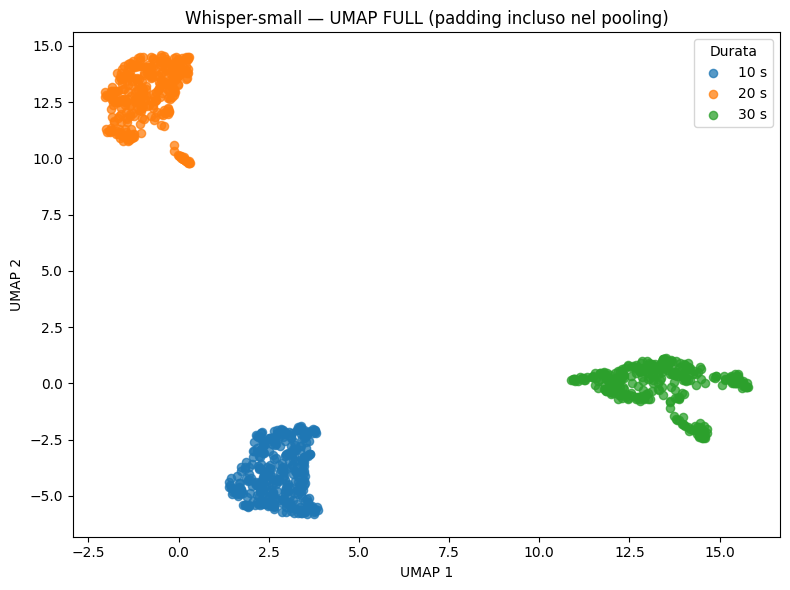

Figura: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\figure\umap_full_per_durata.png


In [13]:

try:
    import umap
except ImportError as exc:
    raise ImportError(
        "umap-learn non è installato. Eseguire la cella %pip."
    ) from exc


def calcola_umap(embedding_norm):
    n_neighbors = min(
        15,
        max(2, len(embedding_norm) - 1),
    )

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        metric="cosine",
        random_state=RANDOM_STATE,
    )

    return reducer.fit_transform(
        embedding_norm
    )


umap_full_values = calcola_umap(
    full_norm
)

umap_full_df = metadata_embedding.copy()
umap_full_df["UMAP1"] = umap_full_values[:, 0]
umap_full_df["UMAP2"] = umap_full_values[:, 1]

UMAP_FULL_CSV = OUTPUT_DIR / "coordinate_umap_full.csv"
umap_full_df.to_csv(UMAP_FULL_CSV, index=False)

plt.figure(figsize=(8, 6))

for durata, gruppo in umap_full_df.groupby(
    "window_size_seconds"
):
    plt.scatter(
        gruppo["UMAP1"],
        gruppo["UMAP2"],
        label=f"{int(durata)} s",
        alpha=0.75,
        s=35,
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Whisper-small — UMAP FULL (padding incluso nel pooling)")
plt.legend(title="Durata")
plt.tight_layout()

UMAP_FULL_PNG = FIGURE_DIR / "umap_full_per_durata.png"
plt.savefig(UMAP_FULL_PNG, dpi=200)
plt.savefig("img/Whisper-small.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura:", UMAP_FULL_PNG)


## 10. UMAP VALID-ONLY — durata della finestra

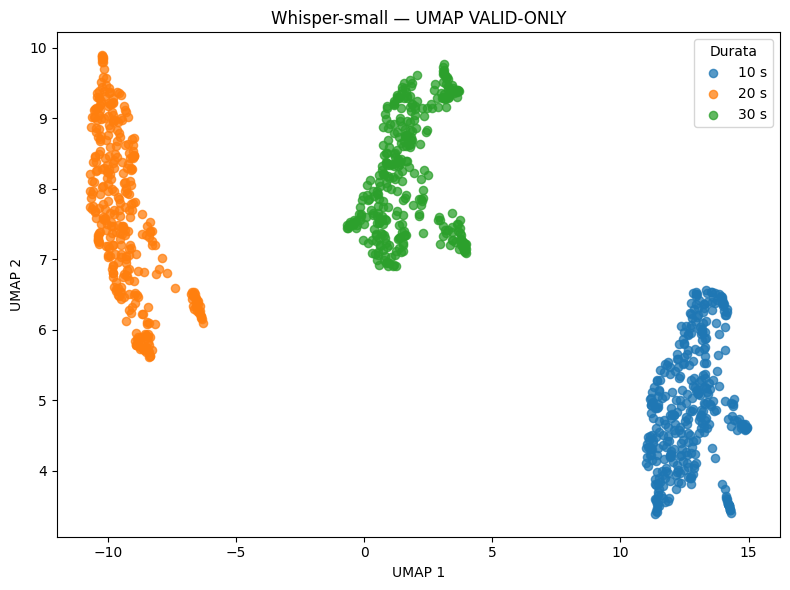

Figura: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\figure\umap_valid_only_per_durata.png


In [15]:

umap_valid_values = calcola_umap(
    valid_norm
)

umap_valid_df = metadata_embedding.copy()
umap_valid_df["UMAP1"] = umap_valid_values[:, 0]
umap_valid_df["UMAP2"] = umap_valid_values[:, 1]

UMAP_VALID_CSV = OUTPUT_DIR / "coordinate_umap_valid_only.csv"
umap_valid_df.to_csv(UMAP_VALID_CSV, index=False)

plt.figure(figsize=(8, 6))

for durata, gruppo in umap_valid_df.groupby(
    "window_size_seconds"
):
    plt.scatter(
        gruppo["UMAP1"],
        gruppo["UMAP2"],
        label=f"{int(durata)} s",
        alpha=0.75,
        s=35,
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Whisper-small — UMAP VALID-ONLY")
plt.legend(title="Durata")
plt.tight_layout()

UMAP_VALID_PNG = FIGURE_DIR / "umap_valid_only_per_durata.png"
plt.savefig(UMAP_VALID_PNG, dpi=200)
plt.savefig("img/Whisper-small-UMAP VALID-ONLY.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figura:", UMAP_VALID_PNG)



## 11. Lettura automatica del test padding

Questa cella non sostituisce l'ispezione dei grafici, ma produce una sintesi
quantitativa coerente con il test:

- forte riduzione del silhouette → il padding contribuiva molto alla separazione;
- riduzione piccola → la durata/contenuto rimane distinguibile anche dopo il
  valid-only pooling.


In [16]:

riduzione_assoluta = (
    silhouette_full - silhouette_valid
)

if abs(silhouette_full) > 1e-12:
    riduzione_relativa = (
        riduzione_assoluta / abs(silhouette_full)
    )
else:
    riduzione_relativa = np.nan

print("Silhouette FULL:", round(float(silhouette_full), 4))
print("Silhouette VALID-ONLY:", round(float(silhouette_valid), 4))
print("Riduzione assoluta:", round(float(riduzione_assoluta), 4))

if np.isfinite(riduzione_relativa):
    print(
        "Riduzione relativa:",
        f"{riduzione_relativa:.1%}",
    )

if silhouette_valid < silhouette_full:
    print(
        "\nLa separazione per durata diminuisce con il "
        "VALID-ONLY pooling: il padding contribuiva alla "
        "struttura osservata."
    )
else:
    print(
        "\nLa separazione per durata non diminuisce con il "
        "VALID-ONLY pooling: il padding nel pooling non "
        "spiega da solo la struttura osservata."
    )


Silhouette FULL: 0.6911
Silhouette VALID-ONLY: 0.5205
Riduzione assoluta: 0.1706
Riduzione relativa: 24.7%

La separazione per durata diminuisce con il VALID-ONLY pooling: il padding contribuiva alla struttura osservata.


## 12. UMAP VALID-ONLY colorata per DN4

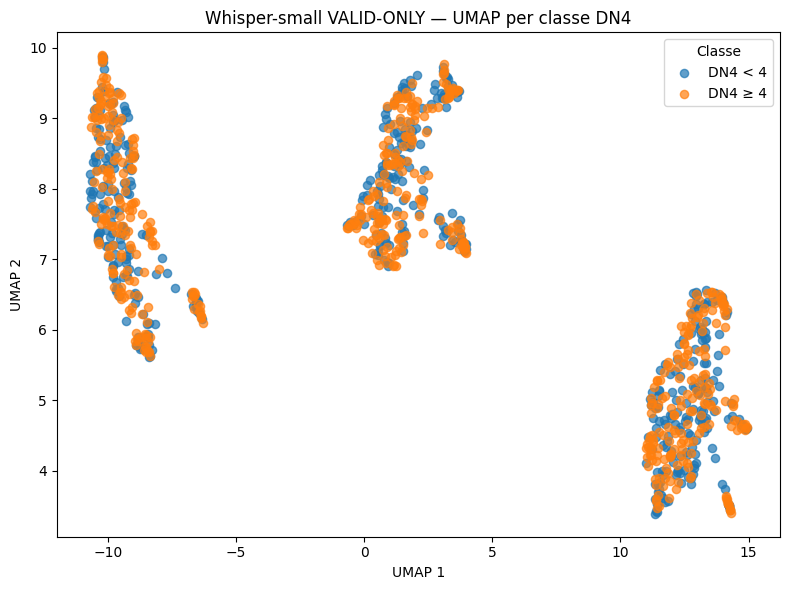

Figura: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\figure\umap_valid_only_dn4.png


In [18]:

if (
    "patient_label" in umap_valid_df.columns
    and umap_valid_df["patient_label"].notna().any()
):
    dn4_df = umap_valid_df[
        umap_valid_df["patient_label"].notna()
    ].copy()

    plt.figure(figsize=(8, 6))

    for label, gruppo in dn4_df.groupby(
        "patient_label"
    ):
        nome = (
            "DN4 ≥ 4"
            if int(label) == 1
            else "DN4 < 4"
        )

        plt.scatter(
            gruppo["UMAP1"],
            gruppo["UMAP2"],
            label=nome,
            alpha=0.7,
            s=35,
        )

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("Whisper-small VALID-ONLY — UMAP per classe DN4")
    plt.legend(title="Classe")
    plt.tight_layout()

    UMAP_DN4_PNG = FIGURE_DIR / "umap_valid_only_dn4.png"
    plt.savefig(UMAP_DN4_PNG, dpi=200)
    plt.savefig("img/Whisper-small VALID ONLY-UMAP per classe DN4.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Figura:", UMAP_DN4_PNG)
else:
    print(
        "DN4 non disponibile: grafico non generato."
    )



## 13. UMAP VALID-ONLY per DN4, separata per durata

Per evitare che la durata 10/20/30 s agisca da confondente, la visualizzazione
DN4 viene ripetuta separatamente per ciascuna durata.


Salvata: img\Whisper-small_VALID-ONLY_10s_DN4.png


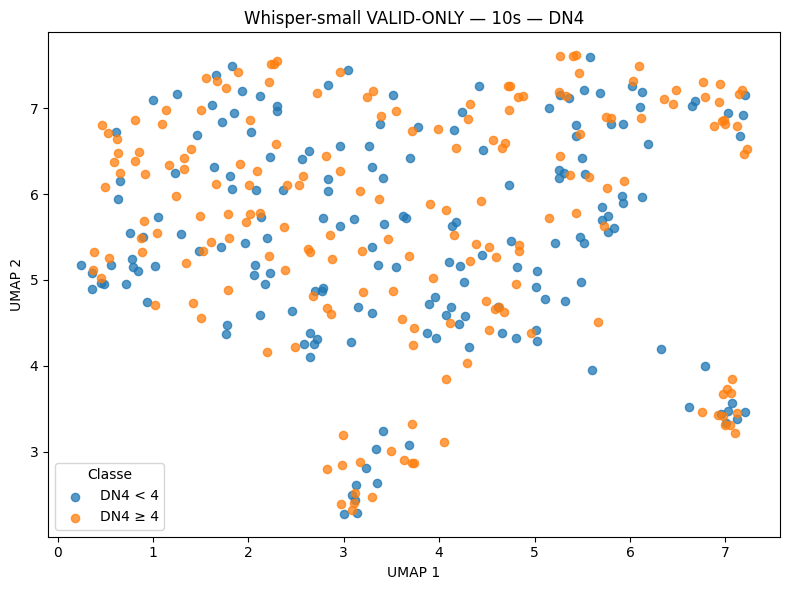

Salvata: img\Whisper-small_VALID-ONLY_20s_DN4.png


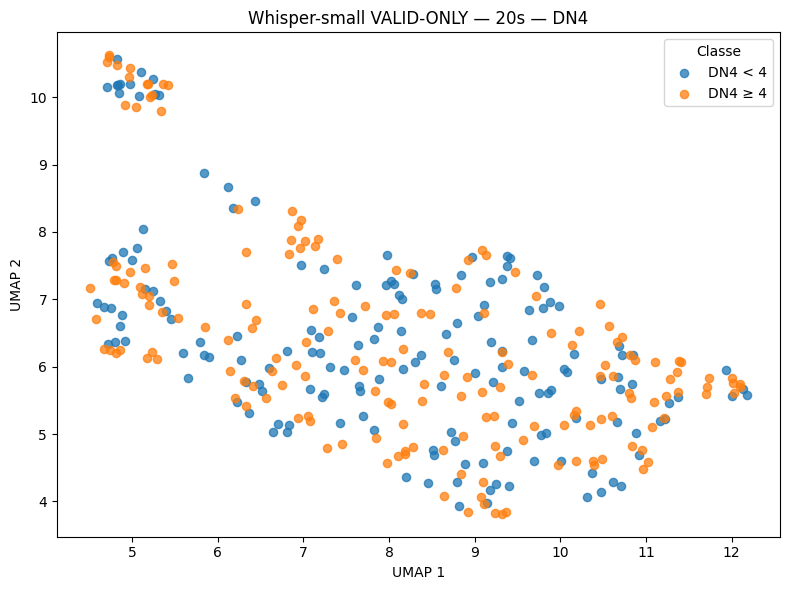

Salvata: img\Whisper-small_VALID-ONLY_30s_DN4.png


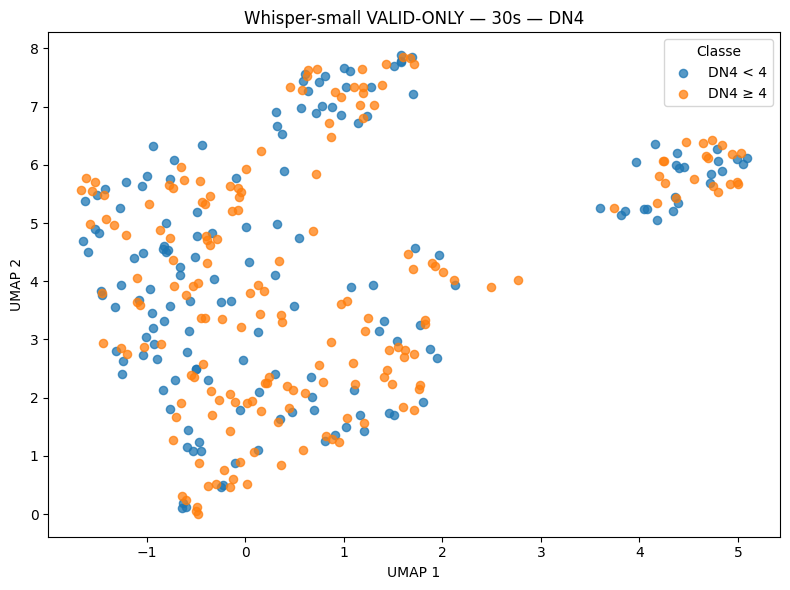

In [23]:
from pathlib import Path

IMG_DIR = Path("img")
IMG_DIR.mkdir(parents=True, exist_ok=True)

if (
    "patient_label" in umap_valid_df.columns
    and umap_valid_df["patient_label"].notna().any()
):
    for durata in [10, 20, 30]:

        maschera = (
            metadata_embedding["window_size_seconds"]
            == durata
        )

        meta_durata = (
            metadata_embedding.loc[maschera]
            .reset_index(drop=True)
        )

        emb_durata = valid_norm[
            maschera.to_numpy()
        ]

        if len(meta_durata) < 6:
            print(
                f"{durata}s: troppo poche clip per UMAP."
            )
            continue

        coord = calcola_umap(
            emb_durata
        )

        tmp = meta_durata.copy()
        tmp["UMAP1"] = coord[:, 0]
        tmp["UMAP2"] = coord[:, 1]

        tmp = tmp[
            tmp["patient_label"].notna()
        ].copy()

        # Crea una NUOVA figura ad ogni iterazione
        fig, ax = plt.subplots(figsize=(8, 6))

        for label, gruppo in tmp.groupby(
            "patient_label"
        ):
            nome = (
                "DN4 ≥ 4"
                if int(label) == 1
                else "DN4 < 4"
            )

            ax.scatter(
                gruppo["UMAP1"],
                gruppo["UMAP2"],
                label=nome,
                alpha=0.75,
                s=35,
            )

        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_title(
            f"Whisper-small VALID-ONLY — "
            f"{durata}s — DN4"
        )

        ax.legend(title="Classe")
        fig.tight_layout()

        # IMPORTANTE: questo deve stare DENTRO il ciclo for
        percorso_img = (
            IMG_DIR
            / f"Whisper-small_VALID-ONLY_{durata}s_DN4.png"
        )

        fig.savefig(
            percorso_img,
            dpi=300,
            bbox_inches="tight"
        )

        print(f"Salvata: {percorso_img}")

        plt.show()
        plt.close(fig)


## 14. Correlazioni esplorative

In [17]:

righe_correlazioni = []

for nome_embedding, pca_df in [
    ("FULL", pca_full_df),
    ("VALID_ONLY", pca_valid_df),
]:
    for componente in ["PCA1", "PCA2"]:
        for variabile in [
            "patient_speech_ratio",
            "window_size_seconds",
        ]:
            rho, p_value = spearmanr(
                pca_df[componente],
                pca_df[variabile],
                nan_policy="omit",
            )

            righe_correlazioni.append({
                "embedding": nome_embedding,
                "componente": componente,
                "variabile": variabile,
                "spearman_rho": rho,
                "p_value_esplorativo": p_value,
            })

correlazioni = pd.DataFrame(
    righe_correlazioni
)

CORRELATION_CSV = (
    OUTPUT_DIR
    / "correlazioni_esplorative_full_vs_valid.csv"
)

correlazioni.to_csv(
    CORRELATION_CSV,
    index=False,
)

display(correlazioni)
print("Salvato in:", CORRELATION_CSV)


,embedding,componente,variabile,spearman_rho,p_value_esplorativo
0,FULL,PCA1,patient_speech_ratio,0.122462,7.756775e-05
1,FULL,PCA1,window_size_seconds,-0.942642,0.000000e+00
2,FULL,PCA2,patient_speech_ratio,-0.095071,2.189070e-03
3,FULL,PCA2,window_size_seconds,-0.184983,1.989283e-09
4,VALID_ONLY,PCA1,patient_speech_ratio,0.114773,2.139307e-04
5,VALID_ONLY,PCA1,window_size_seconds,-0.941750,0.000000e+00
6,VALID_ONLY,PCA2,patient_speech_ratio,-0.101320,1.092125e-03
7,VALID_ONLY,PCA2,window_size_seconds,0.312265,7.245451e-25


Salvato in: c:\Users\acer\Desktop\ProgettoTesi\risultati\embedding_audio_padding\correlazioni_esplorative_full_vs_valid.csv
